In [74]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from matplotlib.ticker import FuncFormatter
import seaborn as sns

import os
while not os.path.isdir('.git'):
    os.chdir('../..')

import matplotlib as mpl
mpl.rcParams["font.family"] = "Avenir"

mpl.rcParams["axes.labelsize"] = 9
mpl.rcParams["xtick.labelsize"] = 9
mpl.rcParams["ytick.labelsize"] = 9
mpl.rcParams["legend.fontsize"] = 9
mpl.rcParams["axes.titlesize"] = 9

# Subthreshold conductance figure

In [13]:
project = "temporal-interference-1"

In [14]:
test_stimulus_1 = 100
test_stimulus_2 = 2500

ltp_frequency = 50
ltp_start = 1000
ltp_duration = 1000

In [15]:
def generate_ltp_spike_times():
    """Generate Poisson-distributed spike times."""
    spikes = []
    t = test_stimulus_1 + int(1000 / ltp_frequency)
    spikes.append(t)

    t = ltp_start
    while t <= ltp_start + ltp_duration:
        spikes.append(t)
        isi = int(1000 / ltp_frequency)
        t += isi

    t = test_stimulus_2
    spikes.append(t)

    return spikes

In [16]:
def match_array_size(*arrays):
    min_len = min(arr.shape[0] for arr in arrays)
    return [arr[:min_len] for arr in arrays]

In [17]:
spikes = generate_ltp_spike_times()

In [19]:
synapse_voltage = pd.read_csv(f"output/{project}/1/ltp/noTI_0.1/synapse_voltage.csv", index_col = 0)

In [20]:
idx = 1

voltage0_9 = pd.read_csv(f"output/{project}/figures/figure2/{idx}_0.9_voltage.csv", index_col = 0)
weights0_9 = pd.read_csv(f"output/{project}/figures/figure2/{idx}_0.9_weights.csv", index_col = 0)

voltage1 = pd.read_csv(f"output/{project}/figures/figure2/{idx}_1_voltage.csv", index_col = 0)
weights1 = pd.read_csv(f"output/{project}/figures/figure2/{idx}_1_weights.csv", index_col = 0)

voltage1_1 = pd.read_csv(f"output/{project}/figures/figure2/{idx}_1.1_voltage.csv", index_col = 0)
weights1_1 = pd.read_csv(f"output/{project}/figures/figure2/{idx}_1.1_weights.csv", index_col = 0)

voltage5 = pd.read_csv(f"output/{project}/{idx}/ltp/1000_5_0.9_0.1/voltage.csv", index_col = 0)
weights5 = pd.read_csv(f"output/{project}/{idx}/ltp/1000_5_0.9_0.1/synapse_weights.csv", index_col = 0)

voltage130 = pd.read_csv(f"output/{project}/{idx}/ltp/1000_130_0.9_0.1/voltage.csv")
weights130 = pd.read_csv(f"output/{project}/{idx}/ltp/1000_130_0.9_0.1/synapse_weights.csv", index_col = 0)

voltage0 = pd.read_csv(f"output/{project}/{idx}/ltp/1000_0_0.32_0.1/voltage.csv")
weights0 = pd.read_csv(f"output/{project}/{idx}/ltp/1000_0_0.32_0.1/synapse_weights.csv")

with open(f"output/{project}/{idx}/subthreshold_conductance.txt", "r") as file:
    conductance = float(file.read())

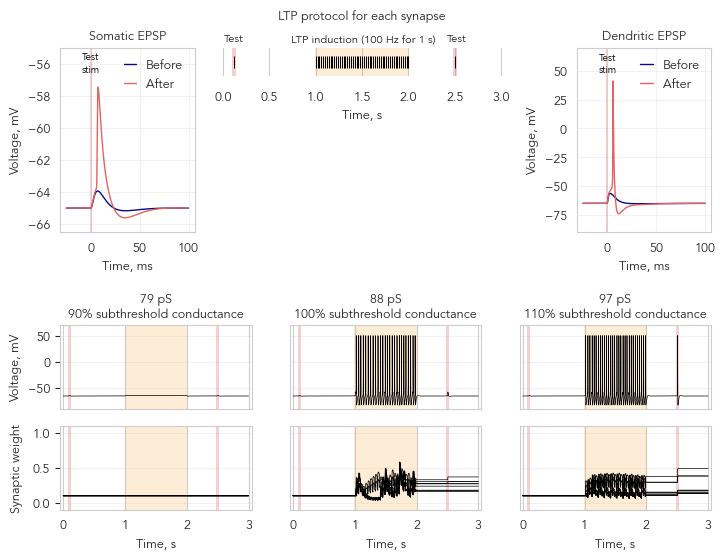

In [31]:
fig = plt.figure(figsize = (8.4, 6))

# outer_gs = gridspec.GridSpec(5, 1, height_ratios = [1, 0.21, 1, 0.13, 1])
outer_gs = gridspec.GridSpec(3, 1, height_ratios = [1, 0.21, 1])

# A B C panels

inner_gs_1 = gridspec.GridSpecFromSubplotSpec(5, 6, subplot_spec = outer_gs[0], width_ratios = [1, -0.1, 1, 1, 0.25, 1], height_ratios = [0.6, 0.05, 1, 1, 1], hspace = 0.075)

##### Dendritic EPSP

ax = fig.add_subplot(inner_gs_1[0:5, 5])

voltage = synapse_voltage
time_before = 25
time_after = 100

time_epsp_before = np.logical_and(voltage.Time > test_stimulus_1 - time_before, voltage.Time < test_stimulus_1 + time_after)
epsp_before = np.array(voltage.Synapse1[time_epsp_before].tolist())

time_epsp_after = np.logical_and(voltage.Time > test_stimulus_2 - time_before, voltage.Time < test_stimulus_2 + time_after)
epsp_after = np.array(voltage.Synapse1[time_epsp_after].tolist())

time = np.array((voltage.Time[time_epsp_before] - test_stimulus_1).tolist())
time, epsp_before, epsp_after = match_array_size(time, epsp_before, epsp_after)

ax.plot(
    time,
    epsp_before,
    color = "#0D0887",
    label = "Before",
    linewidth = 1
)

ax.axvspan(
    -1,
    1,
    alpha = 0.3,
    color = "#E16462",
    zorder = 1,
    linewidth = 0
)

ax.plot(
    time,
    epsp_after,
    color = "#E16462",
    label = "After",
    linewidth = 1
)

ax.grid(alpha = 0.25)

ax.set_ylim(-90, 70)

ax.legend(frameon = False, loc = "upper right", ncol = 1, fontsize = 9, handlelength = 1)

ax.set_ylabel("Voltage, mV")
ax.set_xlabel("Time, ms")

ax.set_title("Dendritic EPSP")

ax.text(
    0, 56,
    "Test\nstim",
    color = "black",
    va = "center",
    ha = "center",
    fontsize = 7
)

# Somatic EPSP

voltage = voltage1
time_before = 25
time_after = 100

ax_a2 = fig.add_subplot(inner_gs_1[0:5, 0])

ax = ax_a2

time_epsp_before = np.logical_and(voltage.Time > test_stimulus_1 - time_before, voltage.Time < test_stimulus_1 + time_after)
epsp_before = np.array(voltage.Voltage[time_epsp_before].tolist())

time_epsp_after = np.logical_and(voltage.Time > test_stimulus_2 - time_before, voltage.Time < test_stimulus_2 + time_after)
epsp_after = np.array(voltage.Voltage[time_epsp_after].tolist())

time = np.array((voltage.Time[time_epsp_before] - test_stimulus_1).tolist())
time, epsp_before, epsp_after = match_array_size(time, epsp_before, epsp_after)

ax.plot(
    time,
    epsp_before,
    color = "#0D0887",
    label = "Before",
    linewidth = 1
)

ax.axvspan(
    -1,
    1,
    alpha = 0.3,
    color = "#E16462",
    zorder = 1,
    linewidth = 0
)

ax.plot(
    time,
    epsp_after,
    color = "#E16462",
    label = "After",
    linewidth = 1
)

ax.set_ylim(-66.5, -55)
ax.set_yticks(np.arange(-66, -55, 2))
ax.grid(alpha = 0.25)

ax.legend(frameon = False, loc = "upper right", ncol = 1, fontsize = 9, handlelength = 1)

ax.set_ylabel("Voltage, mV")
ax.set_xlabel("Time, ms")

ax.set_title("Somatic EPSP")

ax.text(
    0, -56,
    "Test\nstim",
    color = "black",
    va = "center",
    ha = "center",
    fontsize = 7
)

# --- D panel ---

inner_gs = gridspec.GridSpecFromSubplotSpec(2, 3, subplot_spec = outer_gs[2], width_ratios = [1, 1, 1])
axs = np.array([
    [ fig.add_subplot(inner_gs[0, 0]), fig.add_subplot(inner_gs[0, 1]), fig.add_subplot(inner_gs[0, 2]) ],
    [ fig.add_subplot(inner_gs[1, 0]), fig.add_subplot(inner_gs[1, 1]), fig.add_subplot(inner_gs[1, 2]) ]
])

for ax, voltage in zip(axs[0], [voltage0_9, voltage1, voltage1_1]):
    ax.axvspan(
        test_stimulus_1 - 25,
        test_stimulus_1 + 25,
        alpha = 0.3,
        color = "#E16462",
        label = "Test stimulus",
        zorder = 1,
        linewidth = 0
    )

    ax.axvspan(
        test_stimulus_2 - 25,
        test_stimulus_2 + 25,
        alpha = 0.3,
        color = "#E16462",
        zorder = 1,
        linewidth = 0
    )

    ax.axvspan(
        ltp_start - 5,
        ltp_start + ltp_duration + 5,
        alpha = 0.2,
        color = "#FCA636",
        label = "LTP induction",
        zorder = 1,
        linewidth = 0
    )

    ax.plot(
        voltage.Time,
        voltage.Voltage,
        color = "black",
        linewidth = 0.5,
        zorder = 3
    )

    ax.tick_params(bottom = False, labelbottom = False)
    ax.set_ylim(-90, 70)
    ax.set_yticks(np.arange(-50, 100, 50))
    ax.tick_params(left = False, labelleft = False)
    ax.set_xlim(-50, 3050)

    ax.grid(True, alpha = 0.25, axis = "y")

axs[0][0].set_ylabel("Voltage, mV")
axs[0][0].tick_params(left = True, labelleft = True)

for ax, weights in zip(axs[1], [weights0_9, weights1, weights1_1]):
    ax.set_xlabel("Time, s")
    ax.set_xlim(-50, 3050)

    ax.axvspan(
        test_stimulus_1 - 25,
        test_stimulus_1 + 25,
        alpha = 0.3,
        color = "#E16462",
        label = "Test stimulus",
        zorder = 1,
        linewidth = 0
    )

    ax.axvspan(
        test_stimulus_2 - 25,
        test_stimulus_2 + 25,
        alpha = 0.3,
        color = "#E16462",
        zorder = 1,
        linewidth = 0
    )

    ax.axvspan(
        ltp_start - 5,
        ltp_start + ltp_duration + 5,
        alpha = 0.2,
        color = "#FCA636",
        label = "LTP induction",
        zorder = 1,
        linewidth = 0
    )

    for synapse in [f"Synapse{i}" for i in range(10)]:
        ax.plot(
            weights.Time,
            weights[synapse],
            linewidth = 0.5,
            color = "black",
        )

    ax.tick_params(left = False, labelleft = False)
    ax.set_ylim(-0.1, 1.1)

    ax.grid(True, alpha = 0.25, axis = "y")

    ax.xaxis.set_major_formatter(FuncFormatter(lambda x, _: int(x / 1000)))

axs[1][0].tick_params(left = True, labelleft = True)
axs[1][0].set_ylabel("Synaptic weight")

axs[0][0].set_title(f"{round(conductance * 1000_000 * 0.9)} pS\n90% subthreshold conductance")
axs[0][1].set_title(f"{round(conductance * 1000_000)} pS\n100% subthreshold conductance")
axs[0][2].set_title(f"{round(conductance * 1000_000 * 1.1)} pS\n110% subthreshold conductance")

fig.align_ylabels(axs)

###### LTP protocol

ax_a1 = fig.add_subplot(inner_gs_1[0, 2:4])

ax = ax_a1

ax.axvspan(
    test_stimulus_1 - 1,
    test_stimulus_1 + 44,
    alpha = 0.3,
    color = "#E16462",
    label = "Test stimulus",
    zorder = 1,
    linewidth = 0
)

ax.axvspan(
    test_stimulus_2 - 20,
    test_stimulus_2 + 25,
    alpha = 0.3,
    color = "#E16462",
    zorder = 1,
    linewidth = 0
)

ax.axvspan(
    ltp_start - 10,
    ltp_start + ltp_duration + 10,
    alpha = 0.2,
    color = "#FCA636",
    label = "LTP induction: (100 Hz for 1 s)",
    zorder = 1,
    linewidth = 0
)

ax.eventplot(
    spikes,
    lineoffsets = 1,
    linelengths = 1.25,
    colors = "black",
    linewidths = 0.75,
    zorder = 3,
    rasterized = True
)

for spine in ["top", "right", "left"]:
    ax.spines[spine].set_visible(False)

ax.set_ylim(-0.5, 2.5)

ax.set_xlim(-50, 3050)
ax.set_xticks(np.arange(0, 3200, 500))
ax.tick_params(left = False, labelleft = False, labelbottom = False)
ax.set_yticks([])
ax.set_xticklabels([])
ax.spines["bottom"].set_visible(False)

ax.xaxis.set_major_formatter(FuncFormatter(lambda x, _: x / 1000))

ax.set_title("LTP protocol for each synapse", y = 1.7)

fig.text(0.32, 0.89, "Test", fontsize = 8)
fig.text(0.40, 0.89, "LTP induction (100 Hz for 1 s)", fontsize = 8)
fig.text(0.585, 0.89, "Test", fontsize = 8)

###### The BLUE line

ax = fig.add_subplot(inner_gs_1[1, 2:4])

ax.axvspan(
    ltp_start - 20,
    ltp_start + ltp_duration + 25,
    color = "white",
    zorder = 1,
    linewidth = 0
)

ax.set_xlim(-50, 3050)
ax.set_xticks(np.arange(0, 3200, 500))
ax.set_yticks([])
ax.set_ylim(-0.5, 0.5)
ax.tick_params(left = False, labelleft = False)
ax.grid(False)

for spine in ax.spines.values():
    spine.set_visible(False)

ax.xaxis.set_major_formatter(FuncFormatter(lambda x, _: x / 1000))

ax.set_xlabel("Time, s")

# fig.text(0.41, 0.825, "No TI", fontsize = 6, va = "center", ha = "center")

plt.savefig("bernstein-conductance-1.png", dpi = 500, bbox_inches = "tight")

## Distribution of final weights

In [39]:
idxs = np.arange(0, 20)

In [40]:
epsp_before = []
epsp_after = []

time = []

for idx in idxs:
    voltage = pd.read_csv(f"output/{project}/{idx}/ltp/noTI_0.1/voltage.csv")

    time_epsp_before = np.logical_and(voltage.Time > test_stimulus_1 - time_before, voltage.Time < test_stimulus_1 + time_after)
    epsp_before_idx = np.array(voltage.Voltage[time_epsp_before].tolist())
    epsp_before.append(epsp_before_idx)

    time_epsp_after = np.logical_and(voltage.Time > test_stimulus_2 - time_before, voltage.Time < test_stimulus_2 + time_after)
    epsp_after_idx = np.array(voltage.Voltage[time_epsp_after].tolist())
    epsp_after.append(epsp_after_idx)

    time = np.array((voltage.Time[time_epsp_before] - test_stimulus_1).tolist())
    time, epsp_before_idx, epsp_after_idx = match_array_size(time, epsp_before_idx, epsp_after_idx)

epsp_before = np.array(epsp_before).T
epsp_after = np.array(epsp_after).T

time, epsp_before, epsp_after = match_array_size(time, epsp_before, epsp_after)

In [56]:
final_conductance = []
for idx in idxs:
    results = pd.read_csv(f"output/{project}/{idx}/subthreshold_conductance_results.csv")
    final_conductance.append(results.iloc[-1].Conductance)

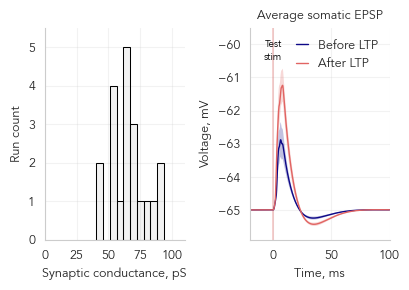

In [78]:
fig, axs = plt.subplots(nrows = 1, ncols = 2, figsize = (8.4 * 0.5, 3))
axs = axs.flatten()

################# Distribution of conductances

ax = axs[0]

ax.hist(np.array(final_conductance) * 1000_000, bins = 10, orientation = "vertical", facecolor = (0, 0, 0, 0.05), edgecolor = "black", linewidth = 0.75)
ax.set_xlabel(r"Synaptic conductance, pS")
ax.set_ylabel("Run count")
ax.set_xlim(0, 110)
ax.set_ylim(0, 5.5)
ax.set_xticks(range(0, 125, 25))
ax.grid(True, alpha = 0.25)

# ax.set_title("Distribution of synaptic conductance")

sns.despine(top = True, right = True, ax = ax)

################# Average EPSP

ax = axs[1]

mean = epsp_before.mean(axis = 1)
error = epsp_before.std(axis = 1)  / np.sqrt(epsp_before.shape[1])

ax.plot(
    time,
    mean,
    linewidth = 1,
    label = "Before LTP",
    color = "#0D0887"
)
ax.fill_between(
    time, mean - error, mean + error,
    alpha = 0.25,
    facecolor = "#0D0887",
    edgecolor = "none"
)

mean = epsp_after.mean(axis = 1)
error = epsp_after.std(axis = 1) / np.sqrt(epsp_after.shape[1])

ax.plot(
    time,
    mean,
    linewidth = 1,
    label = "After LTP",
    color = "#E16462"
)

ax.fill_between(
    time, mean - error, mean + error,
    alpha = 0.25,
    facecolor = "#E16462",
    edgecolor = "none"
)

ax.axvspan(
    -1,
    1,
    alpha = 0.3,
    color = "#E16462",
    zorder = 1,
    linewidth = 0
)

ax.legend(frameon = False, loc = "upper right", ncol = 1, fontsize = 9, handlelength = 1)

ax.set_xlabel("Time, ms")
ax.set_ylabel("Voltage, mV")
ax.set_ylim(-65.9, -59.5)
ax.set_xlim(-20, 100)

ax.grid(True, alpha = 0.25)

ax.text(
    0, -60.2,
    "Test\nstim",
    color = "black",
    va = "center",
    ha = "center",
    fontsize = 7
)

ax.set_title("Average somatic EPSP")

sns.despine(top = True, right = True, ax = ax)

fig.tight_layout()
plt.savefig("bernstein-conductance-2.png", dpi = 500)